In [ ]:
!pip install -U sentence-transformers scikit-learn pandas numpy
!pip install numpy
!pip install scipy

In [ ]:
import pandas as pd
import numpy as np
import time

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [ ]:
modelo = SentenceTransformer("BAAI/bge-m3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
#Dataset
!git clone https://github.com/roneysco/Fake.br-Corpus.git

#Spacy
!python -m spacy download pt_core_news_sm

Cloning into 'Fake.br-Corpus'...
remote: Enumerating objects: 28763, done.
remote: Total 28763 (delta 0), reused 0 (delta 0), pack-reused 28763 (from 1)
Receiving objects: 100% (28763/28763), 37.10 MiB | 19.85 MiB/s, done.
Resolving deltas: 100% (14129/14129), done.
Updating files: 100% (21602/21602), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 104.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
df = pd.read_csv("/content/Fake.br-Corpus/preprocessed/pre-processed.csv")

df.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


### 1. Preparação dos dados e gerar embeddings



In [ ]:
#selecionar colunas e texto e coluna de rótulo
temp_df = df.dropna(subset=['preprocessed_news'])
text_data = temp_df['preprocessed_news'].tolist()
labels = temp_df['label'].tolist()

print(f"Número de texto para embeddings: {len(text_data)}")
print(f"Número de rótulos: {len(labels)}")

Número de texto para embeddings: 7200
Número de rótulos: 7200


In [ ]:
import time
import torch

print("gerando embeddings...")
start_time = time.time()
# Reduzindo o batch_size para economizar memória da GPU e limpando o cache
torch.cuda.empty_cache()
embeddings = modelo.encode(text_data, show_progress_bar=True, batch_size=4)
end_time = time.time()
print(f"Embeddings gerados em {end_time - start_time:.2f} segundos.")

print(f"Formato dos embeddings: {embeddings.shape}")

gerando embeddings...


Batches:   0%|          | 0/1800 [00:00<?, ?it/s]

Embeddings gerados em 1084.30 segundos.
Formato dos embeddings: (7200, 1024)


### 2.  Dividir os dados em conjuntos de treinamento e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42, stratify = labels)

print(f"Tamanho do conjunto de treinamento (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho dos rótulos de treinamento (y_train): {len(y_train)}")
print(f"Tamanho dos rótulos de teste (y_test): {len(y_test)}")

Tamanho do conjunto de treinamento (X_train): (5760, 1024)
Tamanho do conjunto de teste (X_test): (1440, 1024)
Tamanho dos rótulos de treinamento (y_train): 5760
Tamanho dos rótulos de teste (y_test): 1440


### 3. Treinar modelo de classificação

In [ ]:
print("Treinando modelo de classificação...")
start_time = time.time()
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced') # Adicionado class_weight
clf.fit(X_train, y_train)

print(f"Modelo treinado em {time.time() - start_time:.2f} segundos.")
print("Modelo treinado com sucesso!")

Treinando modelo de classificação...
Modelo treinado em 0.20 segundos.
Modelo treinado com sucesso!


### 4. Avaliar o modelo de classificação

In [ ]:
print("Avaliando o modelo...")
y_pred = clf.predict(X_test)

print("Avaliação de modelo:")
print(f"Acurácia: {accuracy_score(y_test, y_pred)}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted')}")
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))

Avaliando o modelo...
Avaliação de modelo:
Acurácia: 0.9541666666666667
F1-Score: 0.9541652520139511
Relatório de classificação:
              precision    recall  f1-score   support

        fake       0.95      0.96      0.95       720
        true       0.96      0.95      0.95       720

    accuracy                           0.95      1440
   macro avg       0.95      0.95      0.95      1440
weighted avg       0.95      0.95      0.95      1440



### 5. Visualizar matriz de confunções

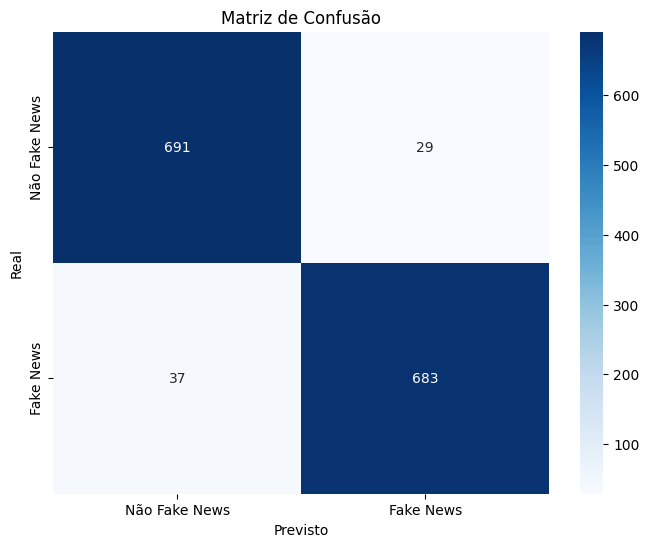

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

### 6. Otimização do Modelo - Ajuste de Hiperparâmetros

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir os hiperparâmetros a serem testados
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Inicializar o GridSearchCV com class_weight='balanced' para a LogisticRegression
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                           param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='f1_weighted', # Avaliar usando F1-Score ponderado
                           n_jobs=-1) # Usar todos os núcleos da CPU

print("Iniciando a busca de hiperparâmetros...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"Busca de hiperparâmetros concluída em {end_time - start_time:.2f} segundos.")

# Exibir os melhores parâmetros e a melhor pontuação
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (validação): {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_clf = grid_search.best_estimator_

# Avaliar o melhor modelo no conjunto de teste
y_pred_optimized = best_clf.predict(X_test)

print("\nAvaliação do modelo otimizado no conjunto de teste:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_optimized, average='weighted'):.4f}")
print("Relatório de classificação:")
print(classification_report(y_test, y_pred_optimized))

Iniciando a busca de hiperparâmetros...
Busca de hiperparâmetros concluída em 207.77 segundos.
Melhores parâmetros encontrados: {'C': 10, 'solver': 'liblinear'}
Melhor F1-Score (validação): 0.9573

Avaliação do modelo otimizado no conjunto de teste:
Acurácia: 0.9590
F1-Score: 0.9590
Relatório de classificação:
              precision    recall  f1-score   support

        fake       0.96      0.96      0.96       720
        true       0.96      0.96      0.96       720

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440



#### Matriz de Confusão do Modelo Otimizado

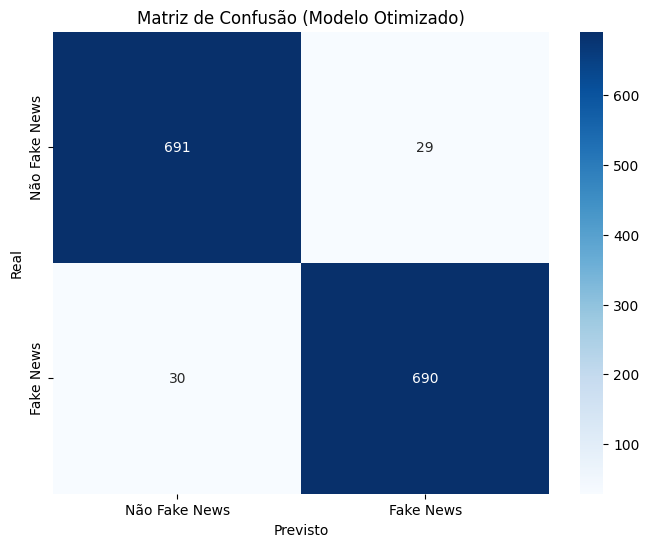

In [ ]:
# Calcular a matriz de confusão para o modelo otimizado
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

# Plotar a matriz de confusão otimizada
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Modelo Otimizado)')
plt.show()

### 7. Treinamento de modelo RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Treinando modelo de classificação Random Forest...")
start_time = time.time()
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Adicionado class_weight
clf_rf.fit(X_train, y_train)

print(f"Modelo treinado em {time.time() - start_time:.2f} segundos.")
print("Modelo treinado com sucesso!")

Treinando modelo de classificação Random Forest...
Modelo treinado em 18.35 segundos.
Modelo treinado com sucesso!


### Avaliando os resultados

In [ ]:
print("Avaliando o modelo...")
y_pred_rf = clf_rf.predict(X_test)

print("Avaliação de modelo:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf)}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='weighted')}")
print("Relatório de classificação:")
print(classification_report(y_test, y_pred_rf))

Avaliando o modelo...
Avaliação de modelo:
Acurácia: 0.9354166666666667
F1-Score: 0.9353827313823666
Relatório de classificação:
              precision    recall  f1-score   support

        fake       0.92      0.96      0.94       720
        true       0.96      0.91      0.93       720

    accuracy                           0.94      1440
   macro avg       0.94      0.94      0.94      1440
weighted avg       0.94      0.94      0.94      1440



### Matriz de confusão - Radom Forest

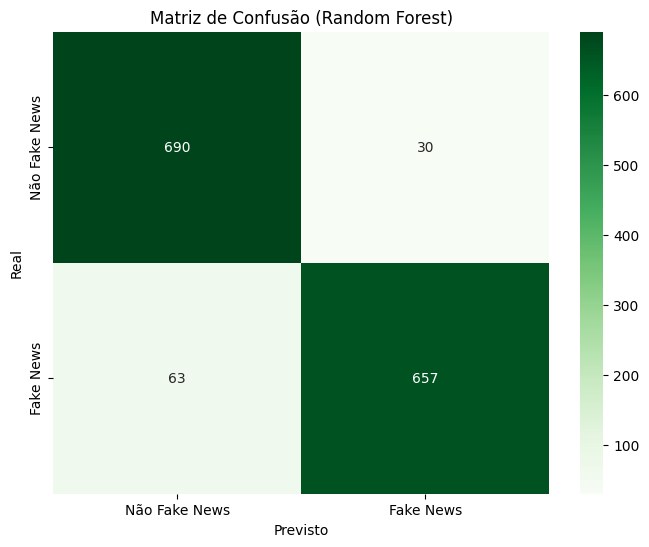

In [ ]:
# Gerar a matriz de confusão para o Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Random Forest)')
plt.show()

### 8. Experimento com SVC

In [ ]:
from sklearn.svm import SVC

print("Treinando o modelo SVM...")
start_time = time.time()

# Criar e treinar o modelo SVM
# Usaremos um kernel linear como ponto de partida e um random_state para reprodutibilidade
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

end_time = time.time()
print(f"Modelo SVM treinado em {end_time - start_time:.2f} segundos.")
print("Modelo SVM treinado com sucesso!")

Treinando o modelo SVM...
Modelo SVM treinado em 4.73 segundos.
Modelo SVM treinado com sucesso!


### Avaliação do modelo

In [ ]:
print("Fazendo previsões no conjunto de teste com SVM...")
y_pred_svm = svm_classifier.predict(X_test)

print("Avaliação do Modelo SVM:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("\nRelatório de Classificação SVM:")
print(classification_report(y_test, y_pred_svm))

Fazendo previsões no conjunto de teste com SVM...
Avaliação do Modelo SVM:
Acurácia: 0.9576
F1-Score (média ponderada): 0.9576

Relatório de Classificação SVM:
              precision    recall  f1-score   support

        fake       0.95      0.96      0.96       720
        true       0.96      0.95      0.96       720

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440



### Visualização da matriz de confusão

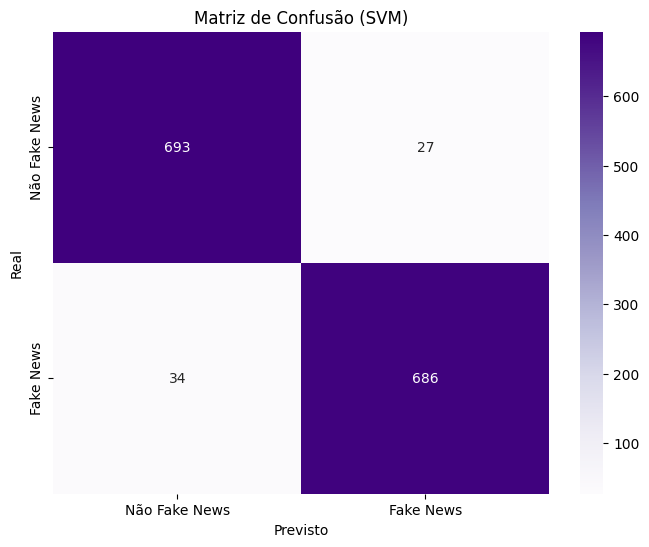

In [ ]:
# Gerar a matriz de confusão para o SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (SVM)')
plt.show()

### 9. Otimização do Modelo Random Forest com GridSearchCV

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Definir os hiperparâmetros a serem testados para o Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Número de árvores na floresta
    'max_depth': [10, 20, None],   # Profundidade máxima da árvore (None significa profundidade ilimitada)
    'min_samples_split': [2, 5, 10], # Número mínimo de amostras para dividir um nó interno
    'min_samples_leaf': [1, 2, 4]    # Número mínimo de amostras necessárias em um nó folha
}

# Inicializar o GridSearchCV para Random Forest
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                              param_grid_rf,
                              cv=3, # Usar 3-fold cross-validation para agilizar
                              scoring='f1_weighted', # Avaliar usando F1-Score ponderado
                              n_jobs=-1, # Usar todos os núcleos da CPU
                              verbose=2) # Para ver o progresso

print("Iniciando a busca de hiperparâmetros para Random Forest...")
start_time_rf_grid = time.time()
grid_search_rf.fit(X_train, y_train)
end_time_rf_grid = time.time()
print(f"Busca de hiperparâmetros para Random Forest concluída em {end_time_rf_grid - start_time_rf_grid:.2f} segundos.")

# Exibir os melhores parâmetros e a melhor pontuação
print(f"Melhores parâmetros encontrados para Random Forest: {grid_search_rf.best_params_}")
print(f"Melhor F1-Score (validação) para Random Forest: {grid_search_rf.best_score_:.4f}")

# Obter o melhor modelo Random Forest
best_clf_rf = grid_search_rf.best_estimator_

# Avaliar o melhor modelo Random Forest no conjunto de teste
y_pred_rf_optimized = best_clf_rf.predict(X_test)

print("\nAvaliação do modelo Random Forest otimizado no conjunto de teste:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_optimized, average='weighted'):.4f}")
print("Relatório de classificação (Random Forest Otimizado):")
print(classification_report(y_test, y_pred_rf_optimized))

Iniciando a busca de hiperparâmetros para Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Busca de hiperparâmetros para Random Forest concluída em 2093.61 segundos.
Melhores parâmetros encontrados para Random Forest: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Melhor F1-Score (validação) para Random Forest: 0.9389

Avaliação do modelo Random Forest otimizado no conjunto de teste:
Acurácia: 0.9361
F1-Score: 0.9361
Relatório de classificação (Random Forest Otimizado):
              precision    recall  f1-score   support

        fake       0.92      0.96      0.94       720
        true       0.95      0.92      0.93       720

    accuracy                           0.94      1440
   macro avg       0.94      0.94      0.94      1440
weighted avg       0.94      0.94      0.94      1440



#### Matriz de Confusão do Modelo Random Forest Otimizado

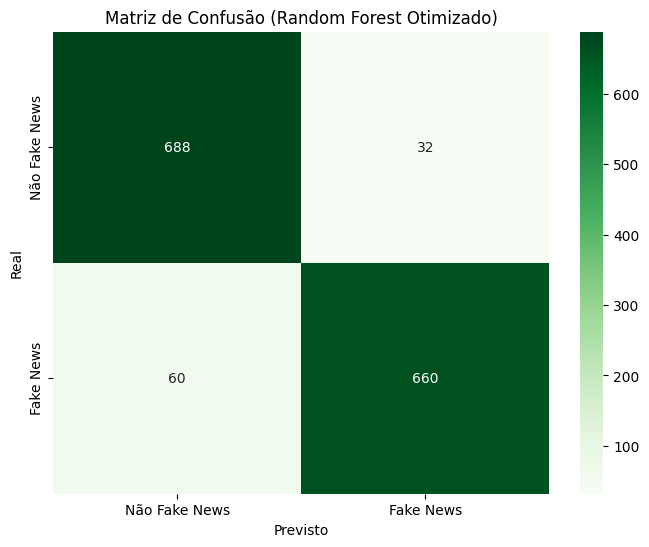

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a matriz de confusão para o modelo Random Forest otimizado
cm_rf_optimized = confusion_matrix(y_test, y_pred_rf_optimized)

# Plotar a matriz de confusão otimizada
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_optimized, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Random Forest Otimizado)')
plt.show()

### 10. Otimização do modelo SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import time

# Definir os hiperparâmetros a serem testados para o SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # 'scale' usa 1 / (n_features * X.var()), 'auto' usa 1 / n_features
}

# Inicializar o GridSearchCV para SVC
grid_search_svm = GridSearchCV(SVC(random_state=42),
                               param_grid_svm,
                               cv=3, # Usar 3-fold cross-validation para agilizar
                               scoring='f1_weighted', # Avaliar usando F1-Score ponderado
                               n_jobs=-1, # Usar todos os núcleos da CPU
                               verbose=2) # Para ver o progresso

print("Iniciando a busca de hiperparâmetros para SVC...")
start_time_svm_grid = time.time()
grid_search_svm.fit(X_train, y_train)
end_time_svm_grid = time.time()
print(f"Busca de hiperparâmetros para SVC concluída em {end_time_svm_grid - start_time_svm_grid:.2f} segundos.")

# Exibir os melhores parâmetros e a melhor pontuação
print(f"Melhores parâmetros encontrados para SVC: {grid_search_svm.best_params_}")
print(f"Melhor F1-Score (validação) para SVC: {grid_search_svm.best_score_:.4f}")

# Obter o melhor modelo SVC
best_clf_svm = grid_search_svm.best_estimator_

# Avaliar o melhor modelo SVC no conjunto de teste
y_pred_svm_optimized = best_clf_svm.predict(X_test)

print("\nAvaliação do modelo SVC otimizado no conjunto de teste:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_optimized, average='weighted'):.4f}")
print("Relatório de classificação (SVC Otimizado):")
print(classification_report(y_test, y_pred_svm_optimized))

Iniciando a busca de hiperparâmetros para SVC...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Busca de hiperparâmetros para SVC concluída em 271.05 segundos.
Melhores parâmetros encontrados para SVC: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Melhor F1-Score (validação) para SVC: 0.9583

Avaliação do modelo SVC otimizado no conjunto de teste:
Acurácia: 0.9618
F1-Score: 0.9618
Relatório de classificação (SVC Otimizado):
              precision    recall  f1-score   support

        fake       0.96      0.96      0.96       720
        true       0.96      0.96      0.96       720

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440



#### Matriz de Confusão do Modelo SVC Otimizado

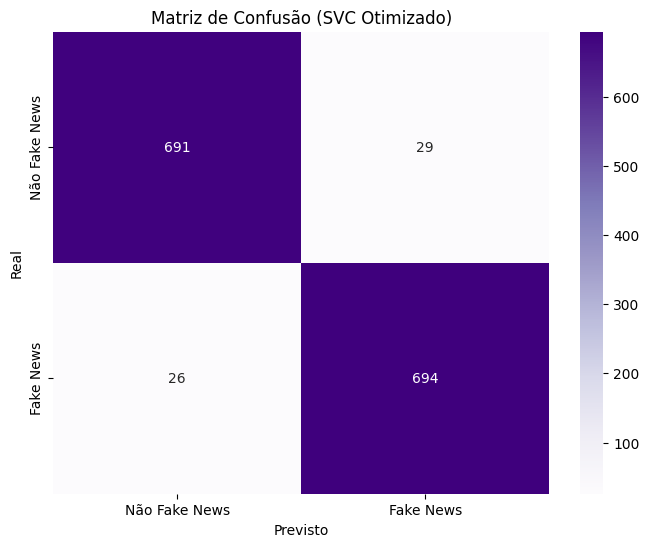

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a matriz de confusão para o modelo SVC otimizado
cm_svm_optimized = confusion_matrix(y_test, y_pred_svm_optimized)

# Plotar a matriz de confusão otimizada
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_optimized, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (SVC Otimizado)')
plt.show()

### 11. Comparação de Desempenho dos Modelos Otimizados

/tmp/ipykernel_6964/1271591937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='F1-Score (Otimizado)', data=df_performance, palette='viridis')


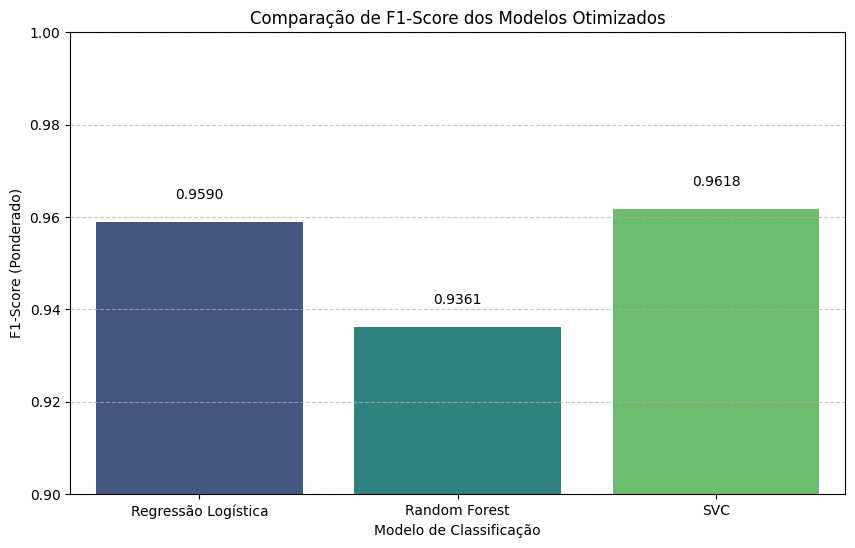

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# F1-Scores dos modelos otimizados (extraídos das saídas anteriores)
f1_logistic_regression = 0.9590
f1_random_forest = 0.9361
f1_svc = 0.9618

# Criar um DataFrame para facilitar a plotagem
data = {
    'Modelo': ['Regressão Logística', 'Random Forest', 'SVC'],
    'F1-Score (Otimizado)': [f1_logistic_regression, f1_random_forest, f1_svc]
}

df_performance = pd.DataFrame(data)

# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-Score (Otimizado)', data=df_performance, palette='viridis')
plt.ylim(0.9, 1.0) # Ajustar o limite Y para melhor visualização das diferenças
plt.title('Comparação de F1-Score dos Modelos Otimizados')
plt.xlabel('Modelo de Classificação')
plt.ylabel('F1-Score (Ponderado)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores exatos nas barras
for index, row in df_performance.iterrows():
    plt.text(index, row['F1-Score (Otimizado)'] + 0.005, f"{row['F1-Score (Otimizado)']:.4f}", color='black', ha="center")

plt.show()